# Cell types by region — Otsu vs AI positivity

Two Opal Studio projects segmented and gated identically, differing only in how marker
positivity was called:

* `lung1_Otsu.zarr` — Otsu thresholding
* `lung1_AI.zarr` — the CNN in `CellMarkerPositivity`

Both carry the same `StarDist_Expand` segmentation, the same two drawn regions
(**Lesion**, **Lung**), and the same cell types from
`imc_all_celltypes_original_gates_corrected.csv`.

This notebook counts how many cells of each type fall in each region, then scores how
cleanly each cell type separates the two regions with **Fisher's linear discriminant**.
A method that assigns positivity better should put the tumour types in the Lesion and
leave them out of the Lung, which shows up as a higher separation score.

**What a cell is.** Type masks are pixel masks, so they are converted back to cells:
a cell belongs to a type when at least `MEMBERSHIP_FRAC` of its pixels are covered.
Every count below is a count of **cells**, not pixels — pixel counts would weight large
cells more heavily and are not what "how many of the types are in each region" means.

In [1]:
from pathlib import Path

# --- the two projects to compare (label -> store) --------------------------
STORES = {
    "Otsu": Path(r"C:/opal-studio/images/SpatialData/lung1_Otsu.zarr"),
    "AI":   Path(r"C:/opal-studio/images/SpatialData/lung1_AI.zarr"),
}

SEGMENTATION = "StarDist_Expand"   # mask channel holding the cell label map
REGIONS = ["Lesion", "Lung"]       # exactly two, in this order
POSITIVE_REGION = "Lesion"         # the region tumour types are expected in

MEMBERSHIP_FRAC = 0.5   # a cell joins a type when this fraction of it is covered
DROP_TYPES = ["Unknown"]  # excluded from the average separation (not a real type)

# Cell types expected to sit in POSITIVE_REGION — used for the direction check.
# Matched case-insensitively as a substring of the type name.
TUMOUR_PATTERNS = ["tumor", "tumour"]

OPAL_STUDIO_REPO = Path(r"C:/opal-studio")   # for `from opal_studio import project_io`

## Loading

In [2]:
import json
import sys

import numpy as np
import pandas as pd

if str(OPAL_STUDIO_REPO) not in sys.path:
    sys.path.insert(0, str(OPAL_STUDIO_REPO))

from opal_studio import project_io
from scipy import ndimage
from skimage.draw import polygon as draw_polygon


def load_store(path):
    '''Return (ProjectDocument, session dict) for an Opal Studio project store.'''
    path = Path(path)
    if not (path / "zarr.json").exists():
        raise FileNotFoundError(f"{path} is not an Opal Studio project store")
    root = json.loads((path / "zarr.json").read_text())
    session = root["attributes"]["opal_studio"]["session"]
    return project_io.load_project(path), session


def channels_of_kind(session, kind):
    '''Channel names of one kind, in the order the project lists them.'''
    return [c["name"] for c in session["channels"] if c.get("kind") == kind]


def rasterise_region(rings_by_id, shape):
    '''Fill a region's polygons into a boolean mask.

    Regions are stored as vector shapes in (x, y); the polygon filler takes
    (row, col), so the two are swapped here.
    '''
    mask = np.zeros(shape, dtype=bool)
    for rings in rings_by_id.values():
        for ring in rings:
            xy = np.asarray(ring, dtype=float)
            if len(xy) < 3:
                continue
            rr, cc = draw_polygon(xy[:, 1], xy[:, 0], shape)
            mask[rr, cc] = True
    return mask

### One project → one row per cell

Each cell gets the region its centroid falls in and a boolean per cell type. Regions can
overlap slightly where the polygons were drawn; a cell in both is assigned to whichever
comes first in `REGIONS`, and the count of such cells is reported so the ambiguity is
visible rather than silent.

**The projects need not carry the same cell types.** Gating only writes out a type that
matched at least one cell, so a type that came up empty under one method is simply
absent from that store. The two are reconciled on the union of their type names, and a
type missing from a store is what its absence means: zero cells. Dropping to the
intersection instead would quietly discard exactly the types where the methods disagree
most.

In [3]:
def cell_table(doc, session):
    '''One row per cell: its region and its membership of every cell type.'''
    if SEGMENTATION not in doc.labels:
        raise KeyError(f"no '{SEGMENTATION}' mask; found {sorted(doc.labels)}")

    cells = np.ascontiguousarray(doc.labels[SEGMENTATION]).astype(np.int32)
    shape = cells.shape
    ids = np.unique(cells)
    ids = ids[ids > 0]
    if ids.size == 0:
        raise ValueError("the segmentation contains no cells")

    # --- region per cell, from its centroid -------------------------------
    centres = np.asarray(ndimage.center_of_mass(cells > 0, cells, ids))
    cy = np.clip(centres[:, 0].astype(int), 0, shape[0] - 1)
    cx = np.clip(centres[:, 1].astype(int), 0, shape[1] - 1)

    region = np.array(["outside"] * ids.size, dtype=object)
    in_region = {}
    for name in REGIONS:
        if name not in doc.shapes:
            raise KeyError(f"no region '{name}'; found {sorted(doc.shapes)}")
        in_region[name] = rasterise_region(doc.shapes[name], shape)[cy, cx]
    # First region in REGIONS wins where they overlap.
    for name in reversed(REGIONS):
        region[in_region[name]] = name
    ambiguous = int(np.count_nonzero(np.sum(list(in_region.values()), axis=0) > 1))

    df = pd.DataFrame({"region": region}, index=pd.Index(ids, name="cell_id"))
    df["centre_y"], df["centre_x"] = cy, cx

    # --- type membership, by how much of each cell the type mask covers ----
    sizes = np.bincount(cells.ravel(), minlength=int(cells.max()) + 1)
    types = channels_of_kind(session, "type_mask")
    for t in types:
        covered = np.bincount(cells[doc.labels[t] > 0].ravel(),
                              minlength=sizes.size)
        with np.errstate(invalid="ignore", divide="ignore"):
            frac = np.where(sizes > 0, covered / np.maximum(sizes, 1), 0.0)
        df[t] = frac[ids] >= MEMBERSHIP_FRAC

    return df, types, ambiguous


tables, own_types, meta = {}, {}, {}
for label, path in STORES.items():
    doc, session = load_store(path)
    df, types, ambiguous = cell_table(doc, session)
    tables[label] = df
    own_types[label] = types
    meta[label] = {"ambiguous": ambiguous, "n_cells": len(df)}

    per_region = df["region"].value_counts()
    print(f"{label:5s}  {len(df):6d} cells  " +
          "  ".join(f"{r}={int(per_region.get(r, 0))}" for r in REGIONS + ["outside"]) +
          f"  (in both regions: {ambiguous})  {len(types)} cell types")

# Union of the type names, first store's order first, then anything new.
type_names = list(own_types[list(STORES)[0]])
for types in own_types.values():
    type_names += [t for t in types if t not in type_names]

# A type a store never wrote out matched no cells there.
for label, df in tables.items():
    for t in type_names:
        if t not in df.columns:
            df[t] = False

print(f"\n{len(type_names)} cell types across all projects")
for label, types in own_types.items():
    missing = [t for t in type_names if t not in types]
    if missing:
        print(f"  absent from '{label}' (no cells matched): {', '.join(missing)}")

Otsu    36260 cells  Lesion=2929  Lung=32560  outside=771  (in both regions: 4)  15 cell types


AI      36260 cells  Lesion=2929  Lung=32560  outside=771  (in both regions: 4)  21 cell types

25 cell types across all projects
  absent from 'Otsu' (no cells matched): Perivascular smooth-muscle-like cells, CAF activated stromal-like cells, ECM fibroblast-like cells, Alveolar macrophage-like cells, CD206 ARG1 macrophage-like cells, CD206-only macrophage-like cells, ARG1-only macrophage-like cells, Other macrophage-like cells, NK cytotoxic-like cells, B-cell-like cells
  absent from 'AI' (no cells matched): Tumor epithelial cells, Tumor mesenchymal-like cells, Blood vascular endothelial cells, MHCII dendritic APC-like cells


### Are the two projects actually different?

The comparison is meaningless if both stores hold the same positivity calls, which is
easy to end up with — the projects differ only by a step that has to have been re-run
and re-saved. This checks it rather than assuming it.

In [4]:
labels = list(STORES)
if len(labels) == 2:
    a, b = labels
    same = [t for t in type_names if tables[a][t].equals(tables[b][t])]
    if len(same) == len(type_names):
        print(f"WARNING: all {len(type_names)} cell types are IDENTICAL between "
              f"'{a}' and '{b}'.")
        print("Both stores hold the same positivity calls, so every comparison below "
              "will show no difference.")
        print("Re-run positivity detection in the project that should differ, save it, "
              "and re-run this notebook.")
    else:
        print(f"{len(type_names) - len(same)} of {len(type_names)} cell types differ "
              f"between '{a}' and '{b}'.\n")
        print(f"  {'cell type':44s} {a:>8s} {b:>8s} {'change':>10s}")
        for t in type_names:
            na, nb = int(tables[a][t].sum()), int(tables[b][t].sum())
            if na != nb:
                note = ""
                if t not in own_types[a]:
                    note = f"  (only in {b})"
                elif t not in own_types[b]:
                    note = f"  (only in {a})"
                print(f"  {t:44s} {na:8d} {nb:8d} {nb - na:+10d}{note}")

25 of 25 cell types differ between 'Otsu' and 'AI'.

  cell type                                        Otsu       AI     change
  Tumor epithelial cells                             91        0        -91  (only in Otsu)
  Tumor mesenchymal-like cells                       13        0        -13  (only in Otsu)
  Tumor other reporter-positive cells              1441        1      -1440
  AT2-like lung epithelial cells                     16       82        +66
  AT1-like alveolar epithelial candidates           160      438       +278
  Other normal epithelial cells                      74       28        -46
  Lymphatic endothelial candidates                   65       68         +3
  Blood vascular endothelial cells                 1019        0      -1019  (only in Otsu)
  Neutrophil-like cells                            1561    11115      +9554
  MHCII dendritic APC-like cells                     79        0        -79  (only in Otsu)
  CD8 lymphocyte-like cells                    

## Cells of each type in each region

In [5]:
def counts_table(df):
    '''Cells per type per region, plus the share of each region's cells.'''
    rows = []
    region_totals = {r: int((df["region"] == r).sum()) for r in REGIONS}
    for t in type_names:
        row = {"cell_type": t}
        for r in REGIONS:
            n = int((df[t] & (df["region"] == r)).sum())
            row[r] = n
            row[f"{r} %"] = 100.0 * n / region_totals[r] if region_totals[r] else np.nan
        row["outside"] = int((df[t] & (df["region"] == "outside")).sum())
        row["total"] = int(df[t].sum())
        rows.append(row)
    out = pd.DataFrame(rows).set_index("cell_type")
    out.attrs["region_totals"] = region_totals
    return out


counts = {label: counts_table(df) for label, df in tables.items()}

for label, tab in counts.items():
    print(f"\n=== {label} ===   region totals: "
          f"{', '.join(f'{r}={n}' for r, n in tab.attrs['region_totals'].items())}")
    display(tab.style.format({**{r: "{:,.0f}" for r in REGIONS},
                              "outside": "{:,.0f}", "total": "{:,.0f}",
                              **{f"{r} %": "{:.2f}%" for r in REGIONS}}))


=== Otsu ===   region totals: Lesion=2929, Lung=32560


,Lesion,Lesion %,Lung,Lung %,outside,total
cell_type,,,,,,
Tumor epithelial cells,72,2.46%,11,0.03%,8,91
Tumor mesenchymal-like cells,11,0.38%,2,0.01%,0,13
Tumor other reporter-positive cells,68,2.32%,"1,331",4.09%,42,"1,441"
AT2-like lung epithelial cells,1,0.03%,14,0.04%,1,16
AT1-like alveolar epithelial candidates,12,0.41%,138,0.42%,10,160
Other normal epithelial cells,0,0.00%,74,0.23%,0,74
Lymphatic endothelial candidates,0,0.00%,65,0.20%,0,65
Blood vascular endothelial cells,4,0.14%,"1,014",3.11%,1,"1,019"
Neutrophil-like cells,9,0.31%,"1,544",4.74%,8,"1,561"



=== AI ===   region totals: Lesion=2929, Lung=32560


,Lesion,Lesion %,Lung,Lung %,outside,total
cell_type,,,,,,
Tumor epithelial cells,0,0.00%,0,0.00%,0,0
Tumor mesenchymal-like cells,0,0.00%,0,0.00%,0,0
Tumor other reporter-positive cells,0,0.00%,1,0.00%,0,1
AT2-like lung epithelial cells,34,1.16%,48,0.15%,0,82
AT1-like alveolar epithelial candidates,9,0.31%,429,1.32%,0,438
Other normal epithelial cells,0,0.00%,28,0.09%,0,28
Lymphatic endothelial candidates,4,0.14%,62,0.19%,2,68
Blood vascular endothelial cells,0,0.00%,0,0.00%,0,0
Neutrophil-like cells,23,0.79%,"11,087",34.05%,5,"11,115"


## Fisher's linear discriminant

For one cell type, score each cell with a 0/1 indicator $x$ — 1 if the cell is of that
type — and split the cells by region. Fisher's criterion for a scalar feature is the
squared gap between the class means over the pooled within-class variance:

$$J \;=\; \frac{(\mu_{\text{Lesion}} - \mu_{\text{Lung}})^2}
                {\sigma^2_{\text{Lesion}} + \sigma^2_{\text{Lung}}}$$

For a 0/1 indicator the class mean is just the fraction of that region's cells carrying
the type, $p$, and the variance is $p(1-p)$, so

$$J \;=\; \frac{(p_{\text{Lesion}} - p_{\text{Lung}})^2}
                {p_{\text{Lesion}}(1-p_{\text{Lesion}}) + p_{\text{Lung}}(1-p_{\text{Lung}})}$$

$J = 0$ means the type is equally common in both regions — it says nothing about where a
cell is. Large $J$ means the type is concentrated in one region and rare in the other,
which is exactly "this cell type is only in one region". $J$ is unsigned, so the
direction is reported separately as the Lesion share of the type's cells.

Cells outside both regions take no part. A type with no cells anywhere scores 0, and a
type present in one region and wholly absent from the other has zero within-class
variance and scores infinity — both are flagged rather than quietly averaged in.

In [6]:
def fisher_separation(indicator, region):
    '''Fisher's discriminant ratio J for a 0/1 indicator across the two regions.'''
    a = indicator[region == REGIONS[0]].astype(float)
    b = indicator[region == REGIONS[1]].astype(float)
    if a.size == 0 or b.size == 0:
        return np.nan
    # ddof=0: for a 0/1 indicator this is exactly p(1-p), matching the formula above.
    num = (a.mean() - b.mean()) ** 2
    den = a.var(ddof=0) + b.var(ddof=0)
    if den == 0:
        return 0.0 if num == 0 else np.inf
    return num / den


def separation_table(df):
    rows = []
    region = df["region"].to_numpy()
    for t in type_names:
        ind = df[t].to_numpy()
        n = {r: int((ind & (region == r)).sum()) for r in REGIONS}
        total = sum(n.values())
        rows.append({
            "cell_type": t,
            "J": fisher_separation(ind, region),
            f"n {REGIONS[0]}": n[REGIONS[0]],
            f"n {REGIONS[1]}": n[REGIONS[1]],
            f"{POSITIVE_REGION} share": (n[POSITIVE_REGION] / total
                                         if total else np.nan),
        })
    return pd.DataFrame(rows).set_index("cell_type")


separations = {label: separation_table(df) for label, df in tables.items()}

scored = [t for t in type_names if t not in DROP_TYPES]
summary = pd.DataFrame({label: tab["J"] for label, tab in separations.items()})
summary = summary.loc[type_names]

print(f"Fisher separation J per cell type  (average over {len(scored)} types, "
      f"excluding {DROP_TYPES})\n")
display(summary.style.format("{:.4f}"))

def mean_J(tab, types):
    col = tab.loc[types, "J"]
    finite = col.replace([np.inf, -np.inf], np.nan).dropna()
    return finite.mean(), finite.median(), int(np.isinf(col).sum())


# A type one method never found scores J = 0 there and pulls its average down, so
# the average over every type answers "which method separates the regions across
# the whole panel". Restricting to the types both methods found answers the
# narrower "where both agree something exists, which separates it better".
shared = [t for t in scored if all(t in own_types[m] for m in STORES)]

print(f"\nAverage over all {len(scored)} types")
for label, tab in separations.items():
    m, med, n_inf = mean_J(tab, scored)
    note = f"   ({n_inf} perfectly separated, left out)" if n_inf else ""
    print(f"  {label:5s}  mean J = {m:.4f}   median = {med:.4f}{note}")

print(f"\nAverage over the {len(shared)} types both methods found")
for label, tab in separations.items():
    m, med, _ = mean_J(tab, shared)
    print(f"  {label:5s}  mean J = {m:.4f}   median = {med:.4f}")

if len(separations) == 2:
    a, b = list(separations)
    for what, types in [("all types  ", scored), ("shared only", shared)]:
        ma, mb = mean_J(separations[a], types)[0], mean_J(separations[b], types)[0]
        if np.isclose(ma, mb):
            print(f"\n  {what}: {a} and {b} separate the regions equally well.")
        else:
            better = a if ma > mb else b
            print(f"\n  {what}: {better} separates better "
                  f"({max(ma, mb):.4f} vs {min(ma, mb):.4f}).")

print("\nJ is unsigned: it says nothing about whether a type landed in the RIGHT region,"
      "\nnor whether a method found the type at all. Check the direction below before"
      "\nreading a higher average as better.")

Fisher separation J per cell type  (average over 24 types, excluding ['Unknown'])



,Otsu,AI
cell_type,,
Tumor epithelial cells,0.0242,0.0000
Tumor mesenchymal-like cells,0.0036,0.0000
Tumor other reporter-positive cells,0.0050,0.0000
AT2-like lung epithelial cells,0.0000,0.0079
AT1-like alveolar epithelial candidates,0.0000,0.0064
Other normal epithelial cells,0.0023,0.0009
Lymphatic endothelial candidates,0.0020,0.0001
Blood vascular endothelial cells,0.0281,0.0000
Neutrophil-like cells,0.0408,0.4763



Average over all 24 types
  Otsu   mean J = 0.0062   median = 0.0000
  AI     mean J = 0.0281   median = 0.0005

Average over the 10 types both methods found
  Otsu   mean J = 0.0090   median = 0.0021
  AI     mean J = 0.0540   median = 0.0036

  all types  : AI separates better (0.0281 vs 0.0062).

  shared only: AI separates better (0.0540 vs 0.0090).

J is unsigned: it says nothing about whether a type landed in the RIGHT region,
nor whether a method found the type at all. Check the direction below before
reading a higher average as better.


### Direction: do the tumour types land in the Lesion?

$J$ is unsigned — a type concentrated in the *wrong* region scores just as highly — so
the direction has to be checked separately.

Two readings, and they can disagree. **Raw counts** ask whether a type has more cells in
the Lesion than in the Lung; that is the literal question, but it is confounded, because
the two regions are nowhere near the same size — whatever fraction of all cells sits in
the Lesion is the level a type with no preference at all would show. **Enrichment**
divides the type's Lesion share by that baseline, so 1.0 means indifferent, above 1.0
means genuinely concentrated in the Lesion. On a small Lesion a strongly
Lesion-specific type can still have fewer cells there in absolute terms, so both are
reported.

In [7]:
tumour = [t for t in type_names
          if any(p in t.lower() for p in TUMOUR_PATTERNS)]
other_region = [r for r in REGIONS if r != POSITIVE_REGION][0]

# What a type with no regional preference would show.
region_totals = counts[list(STORES)[0]].attrs["region_totals"]
baseline = region_totals[POSITIVE_REGION] / sum(region_totals.values())
print(f"{sum(region_totals.values()):,} cells in a region — "
      f"{region_totals[POSITIVE_REGION]:,} in {POSITIVE_REGION}, "
      f"{region_totals[other_region]:,} in {other_region}.")
print(f"A type with no preference would be {baseline:.1%} {POSITIVE_REGION}.\n")

if not tumour:
    print(f"No cell type name matched {TUMOUR_PATTERNS}.")
else:
    rows = []
    for t in tumour:
        row = {"cell_type": t}
        for label, tab in separations.items():
            share = tab.loc[t, f"{POSITIVE_REGION} share"]
            row[f"{label} {POSITIVE_REGION}"] = tab.loc[t, f"n {POSITIVE_REGION}"]
            row[f"{label} {other_region}"] = tab.loc[t, f"n {other_region}"]
            row[f"{label} share"] = share
            row[f"{label} enrich"] = share / baseline if baseline else np.nan
            row[f"{label} J"] = tab.loc[t, "J"]
        rows.append(row)
    tum = pd.DataFrame(rows).set_index("cell_type")
    display(tum.style.format({c: ("{:.1%}" if c.endswith("share")
                                  else "{:.2f}x" if c.endswith("enrich")
                                  else "{:.4f}" if c.endswith("J") else "{:,.0f}")
                              for c in tum.columns}))

    for label, tab in separations.items():
        print(f"\n{label}")
        for t in tumour:
            n_pos = int(tab.loc[t, f"n {POSITIVE_REGION}"])
            n_neg = int(tab.loc[t, f"n {other_region}"])
            head = (f"  {t[:40]:42s} {POSITIVE_REGION}={n_pos:5d} "
                    f"{other_region}={n_neg:5d}")
            if n_pos + n_neg == 0:
                # No cells at all — enrichment is undefined, not "depleted".
                print(f"{head}   NOT FOUND — this method called no cells of this type")
                continue
            enrich = tab.loc[t, f"{POSITIVE_REGION} share"] / baseline
            print(f"{head}   {enrich:5.2f}x baseline"
                  f"   {'enriched' if enrich > 1 else 'depleted'} in {POSITIVE_REGION}")

        n_pos = int(tab.loc[tumour, f"n {POSITIVE_REGION}"].sum())
        n_neg = int(tab.loc[tumour, f"n {other_region}"].sum())
        if n_pos + n_neg == 0:
            print(f"  {'all tumour types together':42s} NO TUMOUR CELLS AT ALL — "
                  f"this method cannot be scored on tumour localisation")
            continue
        share = n_pos / (n_pos + n_neg)
        enrich = share / baseline
        print(f"  {'all tumour types together':42s} {POSITIVE_REGION}={n_pos:5d} "
              f"{other_region}={n_neg:5d}   {enrich:5.2f}x baseline")
        print(f"     raw counts:  {'more' if n_pos > n_neg else 'FEWER'} tumour cells in "
              f"{POSITIVE_REGION} than {other_region}")
        print(f"     enrichment:  {'concentrated in' if enrich > 1 else 'NOT concentrated in'} "
              f"{POSITIVE_REGION} ({share:.1%} vs {baseline:.1%} expected)")

35,489 cells in a region — 2,929 in Lesion, 32,560 in Lung.
A type with no preference would be 8.3% Lesion.



,Otsu Lesion,Otsu Lung,Otsu share,Otsu enrich,Otsu J,AI Lesion,AI Lung,AI share,AI enrich,AI J
cell_type,,,,,,,,,,
Tumor epithelial cells,72,11,86.7%,10.51x,0.0242,0,0,nan%,nanx,0.0000
Tumor mesenchymal-like cells,11,2,84.6%,10.25x,0.0036,0,0,nan%,nanx,0.0000
Tumor other reporter-positive cells,68,"1,331",4.9%,0.59x,0.0050,0,1,0.0%,0.00x,0.0000



Otsu
  Tumor epithelial cells                     Lesion=   72 Lung=   11   10.51x baseline   enriched in Lesion
  Tumor mesenchymal-like cells               Lesion=   11 Lung=    2   10.25x baseline   enriched in Lesion
  Tumor other reporter-positive cells        Lesion=   68 Lung= 1331    0.59x baseline   depleted in Lesion
  all tumour types together                  Lesion=  151 Lung= 1344    1.22x baseline
     raw counts:  FEWER tumour cells in Lesion than Lung
     enrichment:  concentrated in Lesion (10.1% vs 8.3% expected)

AI
  Tumor epithelial cells                     Lesion=    0 Lung=    0   NOT FOUND — this method called no cells of this type
  Tumor mesenchymal-like cells               Lesion=    0 Lung=    0   NOT FOUND — this method called no cells of this type
  Tumor other reporter-positive cells        Lesion=    0 Lung=    1    0.00x baseline   depleted in Lesion
  all tumour types together                  Lesion=    0 Lung=    1    0.00x baseline
     raw coun

## Figures

In [8]:
import matplotlib as mpl
import matplotlib.pyplot as plt

SERIES = ["#2a78d6", "#eb6834"]          # validated categorical slots 1 and 2
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

mpl.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.dpi": 110,
})

### Where the regions are

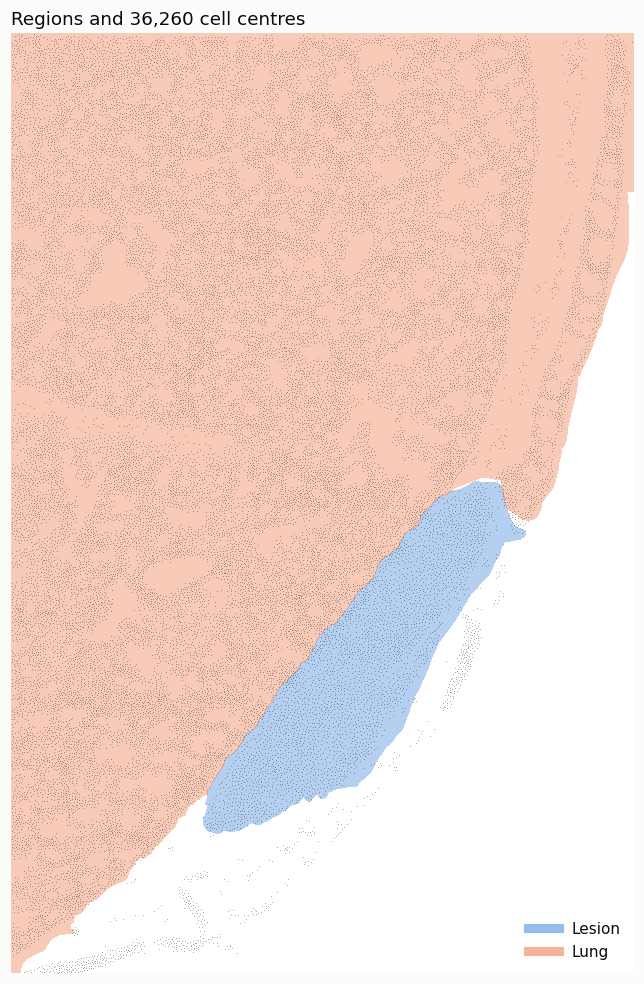

In [9]:
label0 = list(STORES)[0]
doc0, session0 = load_store(STORES[label0])
shape0 = doc0.labels[SEGMENTATION].shape

overlay = np.zeros(shape0, dtype=np.uint8)
for i, r in enumerate(REGIONS, start=1):
    overlay[rasterise_region(doc0.shapes[r], shape0)] = i

fig, ax = plt.subplots(figsize=(6, 6 * shape0[0] / shape0[1]))
ax.imshow(np.ones(shape0), cmap="gray", vmin=0, vmax=1)
for i, r in enumerate(REGIONS, start=1):
    ax.contourf(np.where(overlay == i, 1.0, np.nan), levels=[0.5, 1.5],
                colors=[SERIES[(i - 1) % len(SERIES)]], alpha=0.35)
    ax.plot([], [], color=SERIES[(i - 1) % len(SERIES)], lw=6, alpha=0.5, label=r)
d = tables[label0]
ax.scatter(d["centre_x"], d["centre_y"], s=0.4, c=INK, alpha=0.25, linewidths=0)
ax.set_title(f"Regions and {len(d):,} cell centres", loc="left")
ax.legend(frameon=False, loc="lower right")
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Separation per cell type

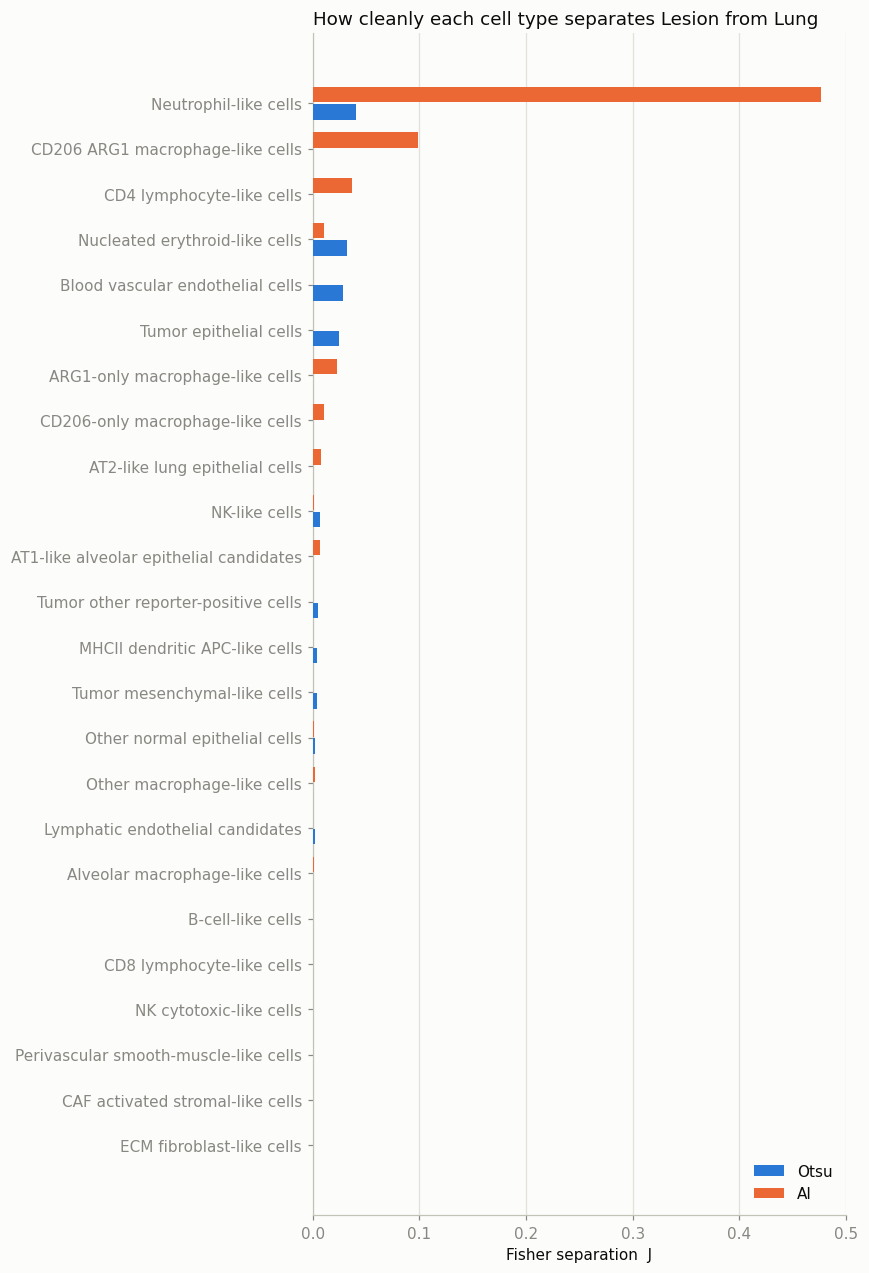

In [10]:
# Both bar charts share this order — sorted by the best separation any method
# reaches — so the two can be read against each other row by row.
order = summary.loc[scored].max(axis=1).sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(8, 0.42 * len(order) + 1.6))
y = np.arange(len(order))
h = 0.38
for i, label in enumerate(STORES):
    vals = separations[label].loc[order, "J"].replace([np.inf], np.nan)
    ax.barh(y + (i - 0.5) * h, vals, height=h - 0.04,
            color=SERIES[i % len(SERIES)], label=label, zorder=3)

ax.set_yticks(y, order)
ax.set_xlabel("Fisher separation  J")
ax.set_title("How cleanly each cell type separates Lesion from Lung", loc="left")
ax.xaxis.grid(True, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

### Where each type's cells sit

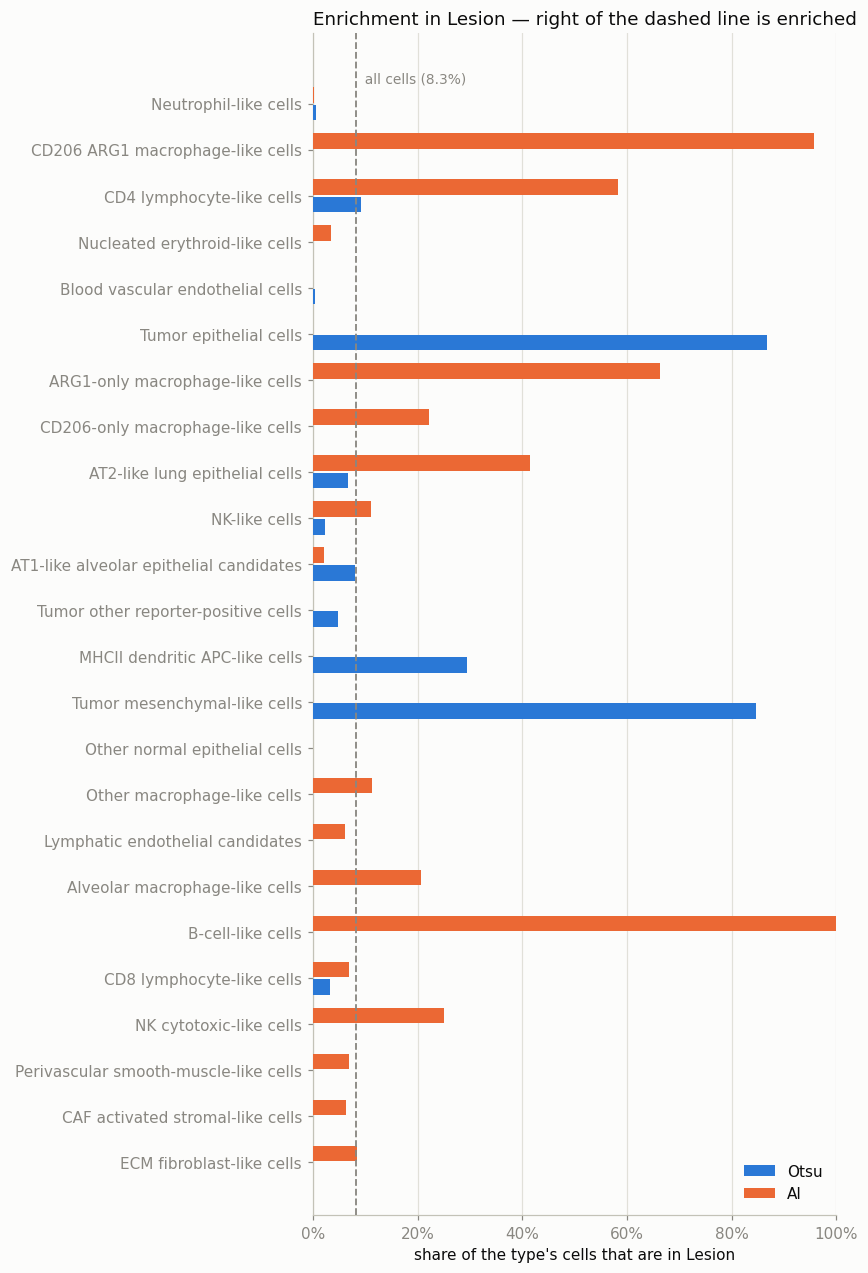

In [11]:
fig, ax = plt.subplots(figsize=(8, 0.42 * len(order) + 1.6))
for i, label in enumerate(STORES):
    share = separations[label].loc[order, f"{POSITIVE_REGION} share"]
    ax.barh(y + (i - 0.5) * h, share, height=h - 0.04,
            color=SERIES[i % len(SERIES)], label=label, zorder=3)

base = (counts[list(STORES)[0]].attrs["region_totals"][POSITIVE_REGION] /
        sum(counts[list(STORES)[0]].attrs["region_totals"].values()))
ax.axvline(base, color=MUTED, lw=1.2, ls="--", zorder=4)
ax.text(base, len(order) - 0.3, f"  all cells ({base:.1%})",
        color=MUTED, va="top", fontsize=9)

ax.set_yticks(y, order)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.set_xlabel(f"share of the type's cells that are in {POSITIVE_REGION}")
ax.set_title(f"Enrichment in {POSITIVE_REGION} — right of the dashed line is enriched",
             loc="left")
ax.xaxis.grid(True, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

## Saving the numbers

In [12]:
out_dir = Path.cwd() / "region_celltype_results"
out_dir.mkdir(exist_ok=True)

for label, tab in counts.items():
    tab.to_csv(out_dir / f"counts_{label}.csv")
for label, tab in separations.items():
    tab.to_csv(out_dir / f"separation_{label}.csv")
summary.to_csv(out_dir / "separation_summary.csv")

print(f"wrote {len(counts) + len(separations) + 1} CSVs to {out_dir}")

wrote 5 CSVs to C:\opal-studio\notebooks\region_celltype_results
